# Pricing and Risk Classification Modeling
 
 In this project, I build a simple auto insurance pricing model using a frequency-severity approach on the French motor insurance dataset. The main goal is to estimate expected loss at the policy level, group policies into risk classes, and compare risk-based pricing against a flat portfolio price.
 
 I use a Poisson model for claim frequency and a Gamma model for claim severity. This is a common actuarial setup because it separates how often claims happen from how large they are when they happen.

## 1. Load and Merge the Data

In this cell I import the basic Python packages and load the frequency and severity files. The severity file has one row per claim, so I first group it by policy and calculate total claim amount and claim count. Then I merge it into the policy data so each row represents one insurance policy.

In [30]:
import numpy as np
import pandas as pd
from pathlib import Path

DATA_DIR = Path("data/raw") if Path("data/raw").exists() else Path("../data/raw")

freq = pd.read_csv(DATA_DIR / "freMTPLfreq.csv")
sev = pd.read_csv(DATA_DIR / "freMTPLsev.csv")

sev_agg = (
    sev.groupby("PolicyID", as_index=False)
       .agg(
           ClaimAmount=("ClaimAmount", "sum"),
           ClaimCountFromSev=("ClaimAmount", "size")
       )
)

df = freq.merge(sev_agg, on="PolicyID", how="left")
df["ClaimAmount"] = df["ClaimAmount"].fillna(0.0)
df["ClaimCountFromSev"] = df["ClaimCountFromSev"].fillna(0).astype(int)

## 2. Clean the Data and Create Targets

Here I do some basic data cleaning before modeling. I cap extreme values, remove rows with invalid exposure, and create simple transformed variables like capped car age, capped driver age, and log density. I also create the main modeling targets: claim frequency, average claim amount, pure premium, and whether the policy had a claim.

In [31]:
# mild outlier / data-quality treatment
df["ClaimNb"] = df["ClaimNb"].clip(upper=4)
df["Exposure"] = df["Exposure"].clip(lower=0, upper=1)
df["ClaimAmount"] = df["ClaimAmount"].clip(upper=200_000)

# if total claim amount is zero, force count to zero
df.loc[(df["ClaimAmount"] == 0) & (df["ClaimNb"] > 0), "ClaimNb"] = 0

# drop impossible exposure rows
df = df[df["Exposure"] > 0].copy()

# small feature engineering
df["CarAgeCapped"] = df["CarAge"].clip(upper=20)
df["DriverAgeCapped"] = df["DriverAge"].clip(lower=18, upper=90)
df["LogDensity"] = np.log1p(df["Density"])

# modeling targets
df["Frequency"] = df["ClaimNb"] / df["Exposure"]
df["AvgClaimAmount"] = df["ClaimAmount"] / np.maximum(df["ClaimNb"], 1)
df["PurePremium"] = df["ClaimAmount"] / df["Exposure"]
df["HasClaim"] = (df["ClaimAmount"] > 0).astype(int)

## 3. Quick Data Check

This cell prints a small summary of the prepared dataset. I check the number of rows, the distribution of claims and exposure, and whether the claim count from the frequency file matches the claim rows from the severity file. This is a simple sanity check before training models.

In [32]:
print(df.shape)
print(df[["ClaimNb", "ClaimCountFromSev", "ClaimAmount", "Exposure"]].describe())
print("Policies with claims:", df["HasClaim"].sum())
print("Mismatch rate ClaimNb vs matched claim rows:",
      (df["ClaimNb"] != df["ClaimCountFromSev"]).mean())

(413169, 19)
             ClaimNb  ClaimCountFromSev    ClaimAmount       Exposure
count  413169.000000      413169.000000  413169.000000  413169.000000
mean        0.039163           0.039163      75.051942       0.560982
std         0.204053           0.204053    1575.095435       0.369304
min         0.000000           0.000000       0.000000       0.002732
25%         0.000000           0.000000       0.000000       0.200000
50%         0.000000           0.000000       0.000000       0.540000
75%         0.000000           0.000000       0.000000       1.000000
max         4.000000           4.000000  200000.000000       1.000000
Policies with claims: 15390
Mismatch rate ClaimNb vs matched claim rows: 0.0


## 4. Split the Data

I split the data into training, validation, and test sets. The training set is used to fit the models, the validation set is used to choose model settings, and the test set is kept for final evaluation. I stratify by `HasClaim` so the claim/no-claim mix stays similar across the splits.

In [33]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["HasClaim"]
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["HasClaim"]
)

## 5. Set Up Model Features

This cell defines which variables go into the models. Numeric variables are standardized, and categorical variables are one-hot encoded so the regression models can use them. The `ColumnTransformer` keeps the preprocessing steps organized inside the model pipeline.

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_cols = [
    "CarAgeCapped",
    "DriverAgeCapped",
    "LogDensity",
]

categorical_cols = [
    "Power",
    "Brand",
    "Gas",
    "Region",
]

feature_cols = numeric_cols + categorical_cols

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
    ],
    remainder="drop",
)

## 6. Train the Frequency Model

Here I train a Poisson regression model to predict claim frequency. Poisson regression is a good fit because claim counts are non-negative and usually rare. I try a few regularization values and choose the one with the lowest weighted validation error.

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import PoissonRegressor

def weighted_mae(y_true, y_pred, weights):
    return np.average(np.abs(y_true - y_pred), weights=weights)

best_freq_model = None
best_freq_alpha = None
best_freq_score = np.inf

for alpha in [1e-6, 1e-4, 1e-2]:
    freq_model = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", PoissonRegressor(alpha=alpha, solver="newton-cholesky", max_iter=300))
    ])

    freq_model.fit(
        train_df[feature_cols],
        train_df["Frequency"],
        model__sample_weight=train_df["Exposure"]
    )

    pred_valid_freq = freq_model.predict(valid_df[feature_cols])
    score = weighted_mae(valid_df["Frequency"], pred_valid_freq, valid_df["Exposure"])

    if score < best_freq_score:
        best_freq_score = score
        best_freq_alpha = alpha
        best_freq_model = freq_model

print(best_freq_alpha, best_freq_score)

0.0001 0.13235542721442353


## 7. Train the Severity Model

This cell trains a Gamma regression model for claim severity, using only policies with positive claim amounts. This makes sense because severity is about how large claims are after a claim happens. I again test a few regularization values and keep the model with the best validation score.

In [36]:
from sklearn.linear_model import GammaRegressor

sev_train = train_df[train_df["ClaimAmount"] > 0].copy()
sev_valid = valid_df[valid_df["ClaimAmount"] > 0].copy()

best_sev_model = None
best_sev_alpha = None
best_sev_score = np.inf

for alpha in [0.1, 1.0, 10.0]:
    sev_model = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", GammaRegressor(alpha=alpha, solver="newton-cholesky", max_iter=300))
    ])

    sev_model.fit(
        sev_train[feature_cols],
        sev_train["AvgClaimAmount"],
        model__sample_weight=sev_train["ClaimNb"]
    )

    pred_valid_sev = sev_model.predict(sev_valid[feature_cols])
    score = weighted_mae(sev_valid["AvgClaimAmount"], pred_valid_sev, sev_valid["ClaimNb"])

    if score < best_sev_score:
        best_sev_score = score
        best_sev_alpha = alpha
        best_sev_model = sev_model

print(best_sev_alpha, best_sev_score)

0.1 1946.4262639611047


## 8. Predict Pure Premium

In this step I combine the frequency and severity models. The expected pure premium is calculated as predicted claim frequency times predicted claim severity. This gives an estimated expected loss cost for each policy.

In [37]:
def add_predictions(data):
    out = data.copy()
    out["PredFreq"] = best_freq_model.predict(out[feature_cols])
    out["PredSev"] = best_sev_model.predict(out[feature_cols])
    out["PredPurePremiumRate"] = out["PredFreq"] * out["PredSev"]
    out["ObservedPurePremiumRate"] = out["ClaimAmount"] / out["Exposure"]
    return out

train_pred = add_predictions(train_df)
test_pred = add_predictions(test_df)

## 9. Create Risk Classes

This cell groups policies into risk classes based on predicted pure premium. I use quantile bins so each class has roughly similar exposure or policy count. The goal is to turn continuous model predictions into easier-to-interpret pricing groups.

In [38]:
train_pred["RiskClass"] = (
    pd.qcut(train_pred["PredPurePremiumRate"], q=10, labels=False, duplicates="drop") + 1
)

cut_points = (
    train_pred.groupby("RiskClass")["PredPurePremiumRate"]
              .max()
              .sort_index()
              .tolist()
)

bins = [-np.inf] + cut_points
labels = list(range(1, len(bins)))

test_pred["RiskClass"] = pd.cut(
    test_pred["PredPurePremiumRate"],
    bins=bins,
    labels=labels,
    include_lowest=True
).astype(int)

## 10. Calculate and Apply Class Prices

Here I calculate the average predicted pure premium for each risk class using the training data. Then I apply those class rates to the test set and compare them with a flat portfolio rate. This lets me see which policies would be underpriced if everyone paid the same average price.

In [39]:
class_rate = train_pred.groupby("RiskClass").apply(
    lambda g: np.average(g["PredPurePremiumRate"], weights=g["Exposure"])
)
class_rate.name = "ClassPurePremiumRate"

portfolio_avg_pure_premium = train_df["ClaimAmount"].sum() / train_df["Exposure"].sum()

test_pred = test_pred.merge(class_rate, left_on="RiskClass", right_index=True, how="left")

test_pred["ModelPremiumRate"] = test_pred["ClassPurePremiumRate"] * 1.30
test_pred["FlatPremiumRate"] = portfolio_avg_pure_premium * 1.30

test_pred["ModelPremium"] = test_pred["ModelPremiumRate"] * test_pred["Exposure"]
test_pred["FlatPremium"] = test_pred["FlatPremiumRate"] * test_pred["Exposure"]

test_pred["PriceGapVsFlat"] = test_pred["ModelPremium"] - test_pred["FlatPremium"]
test_pred["PotentiallyUnderpricedUnderFlat"] = test_pred["PriceGapVsFlat"] > 0

C:\Users\Jacob\AppData\Local\Temp\ipykernel_35196\764955388.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  class_rate = train_pred.groupby("RiskClass").apply(


## 11. Summarize Model Performance

In this cell I summarize results by risk class. I compare actual pure premium, predicted class pure premium, total exposure, claim amount, and loss ratios. This makes it easier to see whether higher-risk classes actually have higher losses.

In [40]:
summary = (
    test_pred.groupby("RiskClass")
    .apply(lambda g: pd.Series({
        "Policies": len(g),
        "Exposure": g["Exposure"].sum(),
        "ActualClaims": g["ClaimAmount"].sum(),
        "ActualPurePremiumRate": g["ClaimAmount"].sum() / g["Exposure"].sum(),
        "AvgPredPurePremiumRate": np.average(g["PredPurePremiumRate"], weights=g["Exposure"]),
        "ClassPurePremiumRate": np.average(g["ClassPurePremiumRate"], weights=g["Exposure"]),
        "ModelPremiumCollected": g["ModelPremium"].sum(),
        "FlatPremiumCollected": g["FlatPremium"].sum(),
        "ModelLossRatio": g["ClaimAmount"].sum() / g["ModelPremium"].sum(),
        "FlatLossRatio": g["ClaimAmount"].sum() / g["FlatPremium"].sum(),
        "PotentiallyUnderpricedShare": g["PotentiallyUnderpricedUnderFlat"].mean(),
    }))
    .reset_index()
)

print(summary.round(4))

   RiskClass  Policies   Exposure  ActualClaims  ActualPurePremiumRate  \
0          1    6174.0  4263.0045      578390.0               135.6766   
1          2    6160.0  3897.2016      353244.0                90.6404   
2          3    6087.0  3676.2844      414020.0               112.6191   
3          4    6223.0  3655.5438      343001.0                93.8304   
4          5    6328.0  3629.6174      377463.0               103.9953   
5          6    6249.0  3467.3440      506631.0               146.1150   
6          7    6121.0  3211.7068      401333.0               124.9594   
7          8    6165.0  3165.4413      626426.0               197.8953   
8          9    6345.0  3105.6541      498022.0               160.3598   
9         10    6124.0  2683.1041      438455.0               163.4133   

   AvgPredPurePremiumRate  ClassPurePremiumRate  ModelPremiumCollected  \
0                 77.6686               77.6786            430487.4098   
1                 95.6977            

C:\Users\Jacob\AppData\Local\Temp\ipykernel_35196\3112549337.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


## 12. Plot the Results

Finally, I make plots to compare actual and predicted pure premium by risk class, and to compare loss ratios under risk-based pricing versus flat pricing. The plots help communicate the modeling results more clearly than a table alone.

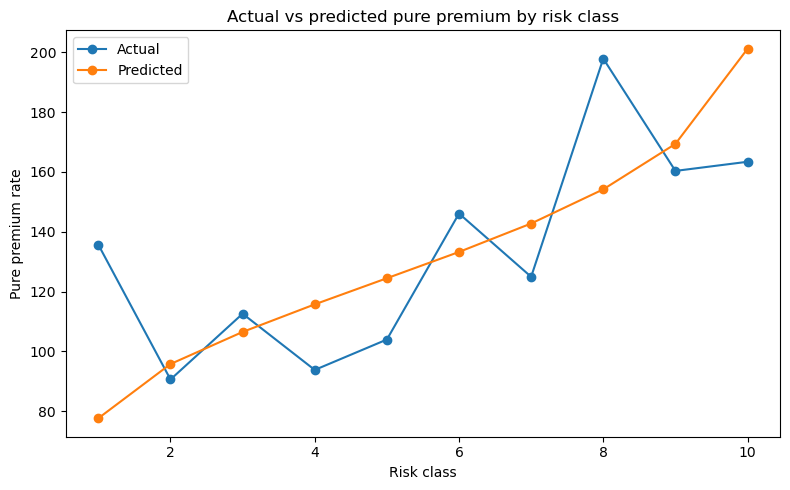

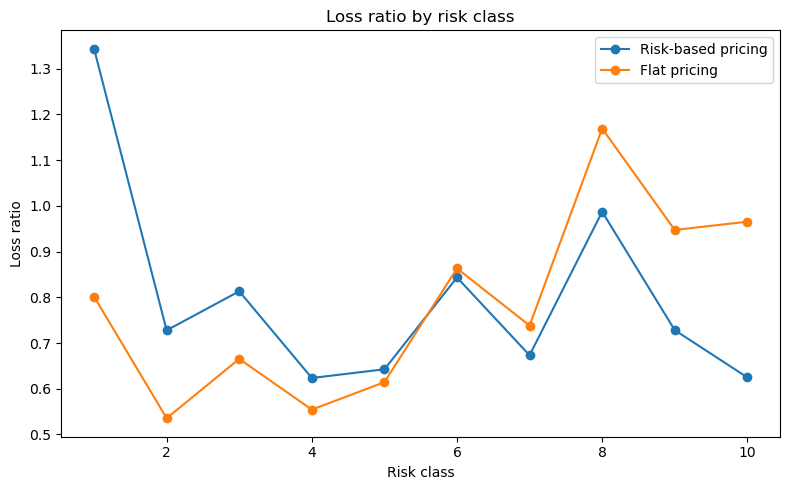

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(summary["RiskClass"], summary["ActualPurePremiumRate"], marker="o", label="Actual")
plt.plot(summary["RiskClass"], summary["ClassPurePremiumRate"], marker="o", label="Predicted")
plt.xlabel("Risk class")
plt.ylabel("Pure premium rate")
plt.title("Actual vs predicted pure premium by risk class")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/actual_vs_predicted_pure_premium_by_class.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(summary["RiskClass"], summary["ModelLossRatio"], marker="o", label="Risk-based pricing")
plt.plot(summary["RiskClass"], summary["FlatLossRatio"], marker="o", label="Flat pricing")
plt.xlabel("Risk class")
plt.ylabel("Loss ratio")
plt.title("Loss ratio by risk class")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/loss_ratio_by_risk_class.png", dpi=300, bbox_inches="tight")
plt.show()